In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('country_wise_latest.csv')
print("Shape:", df.shape)
df.head()

Shape: (187, 15)


,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa


In [2]:
display(df.info())
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country/Region          187 non-null    object 
 1   Confirmed               187 non-null    int64  
 2   Deaths                  187 non-null    int64  
 3   Recovered               187 non-null    int64  
 4   Active                  187 non-null    int64  
 5   New cases               187 non-null    int64  
 6   New deaths              187 non-null    int64  
 7   New recovered           187 non-null    int64  
 8   Deaths / 100 Cases      187 non-null    float64
 9   Recovered / 100 Cases   187 non-null    float64
 10  Deaths / 100 Recovered  187 non-null    float64
 11  Confirmed last week     187 non-null    int64  
 12  1 week change           187 non-null    int64  
 13  1 week % increase       187 non-null    float64
 14  WHO Region              187 non-null    ob

None

,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase
count,1.870000e+02,187.000000,1.870000e+02,1.870000e+02,187.000000,187.000000,187.000000,187.000000,187.000000,187.00,1.870000e+02,187.000000,187.000000
mean,8.813094e+04,3497.518717,5.063148e+04,3.400194e+04,1222.957219,28.957219,933.812834,3.019519,64.820535,inf,7.868248e+04,9448.459893,13.606203
std,3.833187e+05,14100.002482,1.901882e+05,2.133262e+05,5710.374790,120.037173,4197.719635,3.454302,26.287694,NaN,3.382737e+05,47491.127684,24.509838
min,1.000000e+01,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,1.000000e+01,-47.000000,-3.840000
25%,1.114000e+03,18.500000,6.265000e+02,1.415000e+02,4.000000,0.000000,0.000000,0.945000,48.770000,1.45,1.051500e+03,49.000000,2.775000
50%,5.059000e+03,108.000000,2.815000e+03,1.600000e+03,49.000000,1.000000,22.000000,2.150000,71.320000,3.62,5.020000e+03,432.000000,6.890000
75%,4.046050e+04,734.000000,2.260600e+04,9.149000e+03,419.500000,6.000000,221.000000,3.875000,86.885000,6.44,3.708050e+04,3172.000000,16.855000
max,4.290259e+06,148011.000000,1.846641e+06,2.816444e+06,56336.000000,1076.000000,33728.000000,28.560000,100.000000,inf,3.834677e+06,455582.000000,226.320000


In [3]:
print("Missing values:\n", df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

Missing values:
 Country/Region            0
Confirmed                 0
Deaths                    0
Recovered                 0
Active                    0
New cases                 0
New deaths                0
New recovered             0
Deaths / 100 Cases        0
Recovered / 100 Cases     0
Deaths / 100 Recovered    0
Confirmed last week       0
1 week change             0
1 week % increase         0
WHO Region                0
dtype: int64
Duplicates: 0


/tmp/ipykernel_421/943180426.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, x='Confirmed', y='Country/Region', palette='Reds_r')


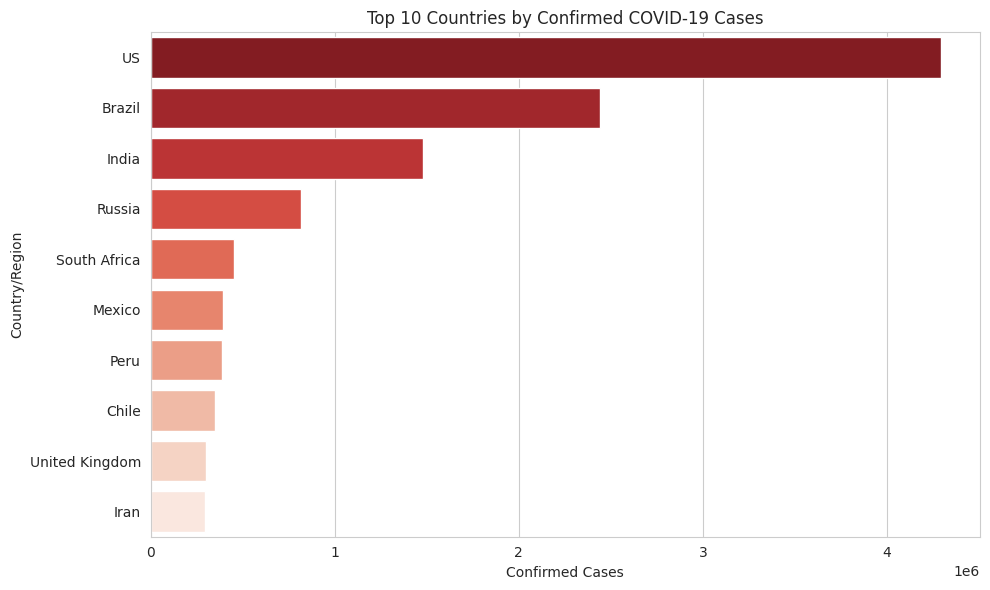

In [4]:
top10 = df.nlargest(10, 'Confirmed')

plt.figure(figsize=(10,6))
sns.barplot(data=top10, x='Confirmed', y='Country/Region', palette='Reds_r')
plt.title('Top 10 Countries by Confirmed COVID-19 Cases')
plt.xlabel('Confirmed Cases')
plt.tight_layout()
plt.show()

/tmp/ipykernel_421/337858688.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_deaths, x='Deaths', y='Country/Region', palette='Blues_r')


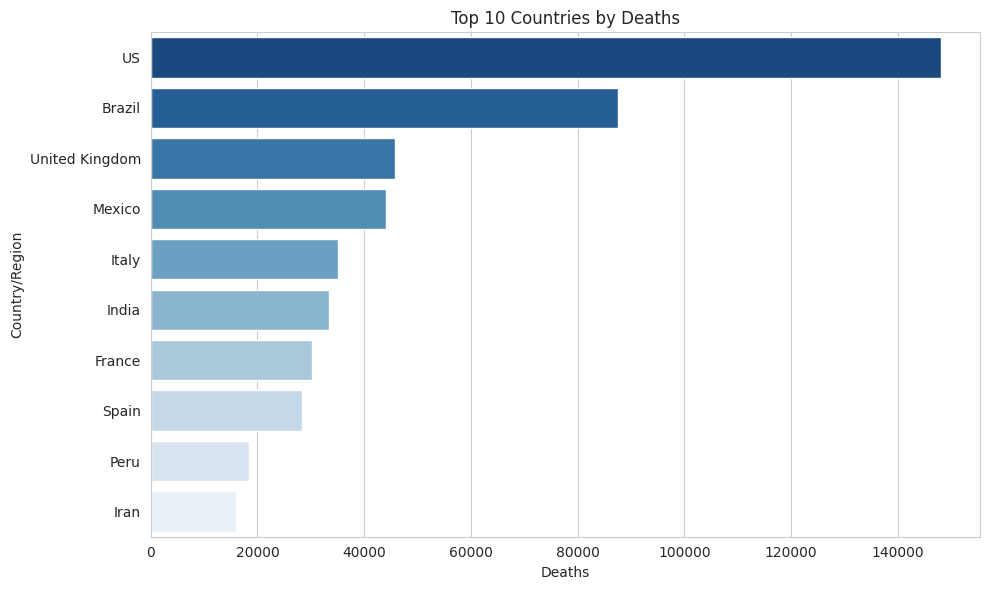

In [5]:
top10_deaths = df.nlargest(10, 'Deaths')

plt.figure(figsize=(10,6))
sns.barplot(data=top10_deaths, x='Deaths', y='Country/Region', palette='Blues_r')
plt.title('Top 10 Countries by Deaths')
plt.tight_layout()
plt.show()

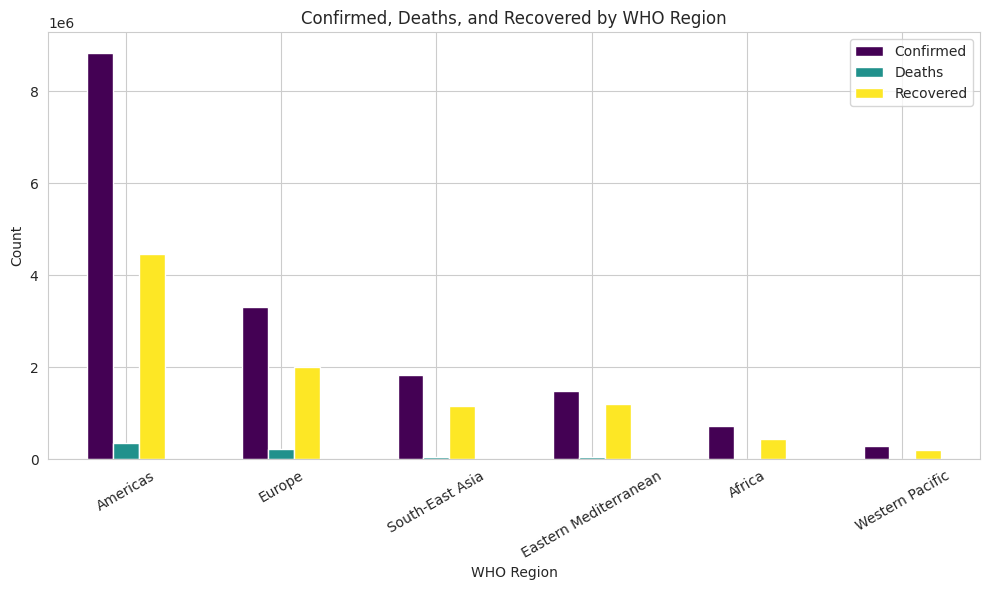

In [6]:
region_totals = df.groupby('WHO Region')[['Confirmed','Deaths','Recovered']].sum().sort_values('Confirmed', ascending=False)

region_totals.plot(kind='bar', figsize=(10,6), colormap='viridis')
plt.title('Confirmed, Deaths, and Recovered by WHO Region')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

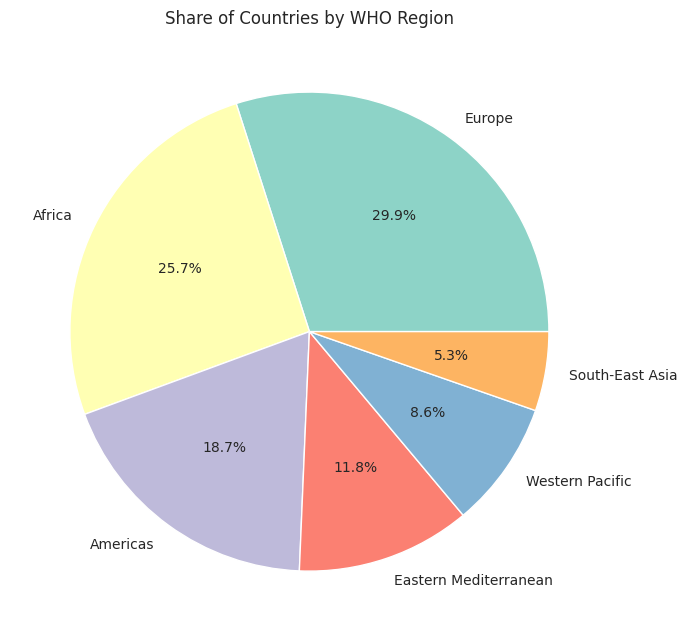

In [7]:
plt.figure(figsize=(7,7))
df['WHO Region'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=sns.color_palette('Set3'))
plt.title('Share of Countries by WHO Region')
plt.ylabel('')
plt.tight_layout()
plt.show()

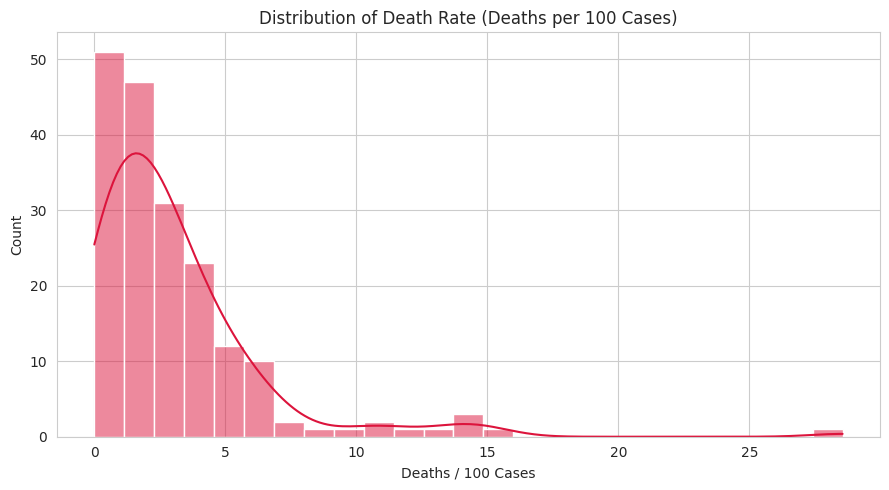

In [8]:
plt.figure(figsize=(9,5))
sns.histplot(df['Deaths / 100 Cases'], bins=25, kde=True, color='crimson')
plt.title('Distribution of Death Rate (Deaths per 100 Cases)')
plt.xlabel('Deaths / 100 Cases')
plt.tight_layout()
plt.show()

/tmp/ipykernel_421/3403843805.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='WHO Region', y='Deaths / 100 Cases', palette='coolwarm')


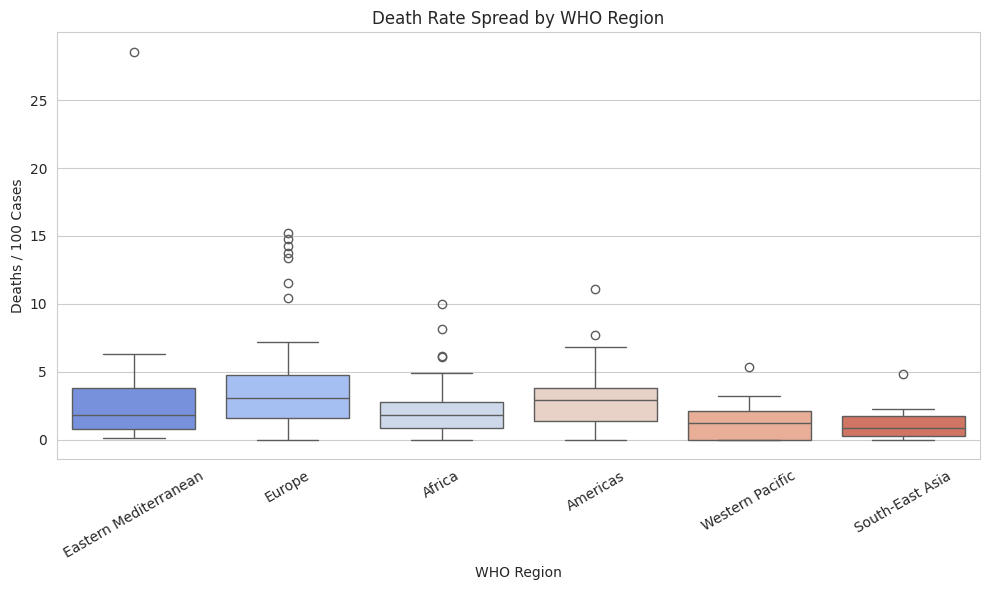

In [9]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='WHO Region', y='Deaths / 100 Cases', palette='coolwarm')
plt.title('Death Rate Spread by WHO Region')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

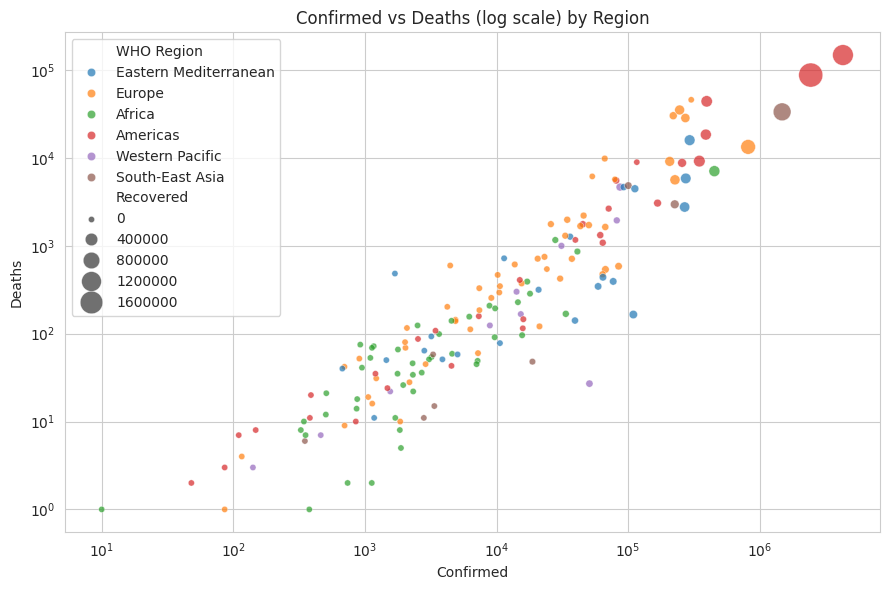

In [10]:
plt.figure(figsize=(9,6))
sns.scatterplot(data=df, x='Confirmed', y='Deaths', hue='WHO Region', size='Recovered', sizes=(20,300), alpha=0.7)
plt.xscale('log')
plt.yscale('log')
plt.title('Confirmed vs Deaths (log scale) by Region')
plt.tight_layout()
plt.show()

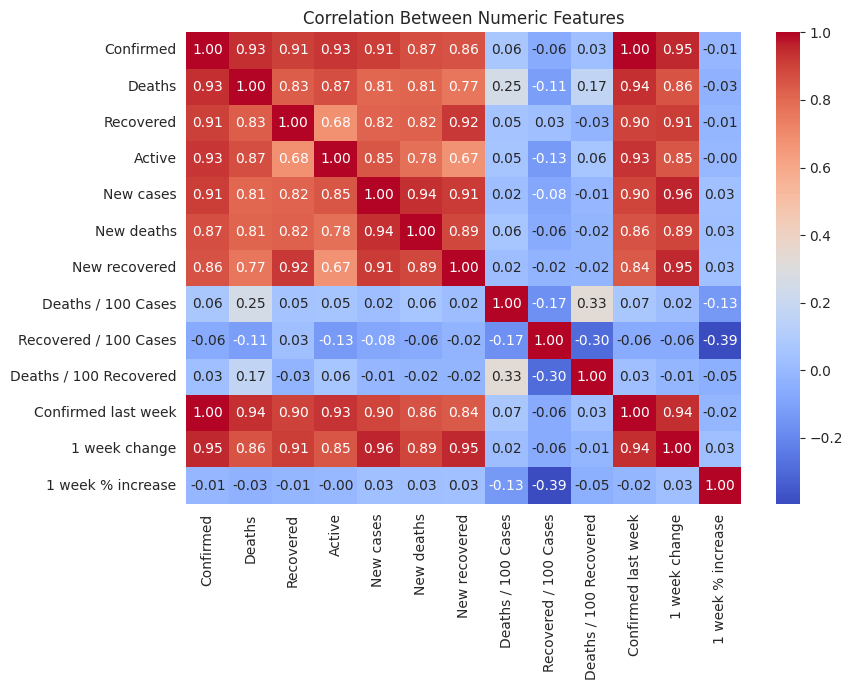

In [11]:
plt.figure(figsize=(9,7))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Numeric Features')
plt.tight_layout()
plt.show()

In [12]:
fig = px.choropleth(
    df,
    locations='Country/Region',
    locationmode='country names',
    color='Confirmed',
    hover_name='Country/Region',
    color_continuous_scale='Reds',
    title='Global COVID-19 Confirmed Cases'
)
fig.show()

In [13]:
top_recovery = df.nlargest(15, 'Recovered / 100 Cases')
fig = px.bar(
    top_recovery,
    x='Country/Region',
    y='Recovered / 100 Cases',
    color='WHO Region',
    title='Top 15 Countries by Recovery Rate'
)
fig.show()

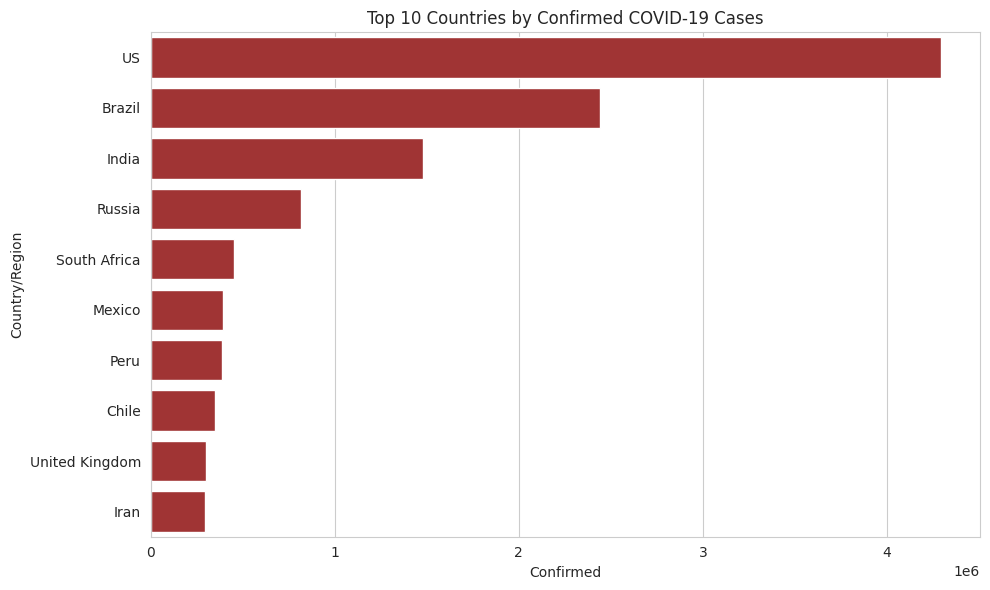

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
from google.colab import files

plt.figure(figsize=(10,6))
sns.barplot(data=top10, x='Confirmed', y='Country/Region', color='firebrick')
plt.title('Top 10 Countries by Confirmed COVID-19 Cases')
plt.tight_layout()
plt.savefig('top10_confirmed.png', dpi=300)
plt.show()

files.download('top10_confirmed.png')